# Classification Results Summary

This notebook summarises the locked ADHD/autism frame-classification layer for reporting. It does not train or apply a classifier; it reads the existing frame-label outputs and writes compact tables, a LaTeX validation table, and one report-ready composition figure.


## Setup

The figure uses publication year (`lsc_year`) because the frame labels are attached to the shared LSC context table. `substantive_other` remains in the tables but is omitted from the figure because it is sparse and not central to the clinical/lived-experience contrast.


In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 160)
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": "#263238",
        "axes.labelcolor": "#263238",
        "axes.titlecolor": "#263238",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": "#D7DEE2",
        "grid.linewidth": 0.8,
        "grid.alpha": 0.7,
        "font.family": "DejaVu Sans",
        "font.size": 10.5,
        "legend.frameon": False,
        "xtick.color": "#263238",
        "ytick.color": "#263238",
    }
)


def find_project_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / "configs/commoncrawl_collection.yaml").exists() and (path / "data").exists():
            return path
    raise FileNotFoundError("Could not locate repository root from current working directory.")


PROJECT_ROOT = find_project_root(Path.cwd())
CLASSIFICATION_DIR = PROJECT_ROOT / "data/processed/lsc/classification"
TARGET_POOL_PATH = PROJECT_ROOT / "data/interim/lsc/classification/frame_target_context_pool.csv"
LABEL_PATH = CLASSIFICATION_DIR / "lsc_target_context_frame_labels.csv"
COUNTS_PATH = CLASSIFICATION_DIR / "lsc_frame_counts_by_year_unit.csv"
METRICS_PATH = CLASSIFICATION_DIR / "frame_classifier_validation_metrics.csv"
TABLE_DIR = PROJECT_ROOT / "reports/tables/lsc/classification"
FIGURE_DIR = PROJECT_ROOT / "reports/figures/lsc/classification"
for path in [TABLE_DIR, FIGURE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

EXPECTED_CODEBOOK_VERSION = "v0.4"
TARGET_UNITS = ["ADHD", "Autism"]
DISPLAY_FRAMES = ["clinical_only", "lived_only", "mixed", "non_substantive_or_insufficient"]
FRAME_LABELS = {
    "clinical_only": "Clinical/disorder",
    "lived_only": "Lived experience",
    "mixed": "Mixed",
    "non_substantive_or_insufficient": "Non-substantive",
}
FRAME_COLOURS = {
    "clinical_only": "#4F8DB3",
    "lived_only": "#C98263",
    "mixed": "#79A889",
    "non_substantive_or_insufficient": "#B8C0C5",
}


## Load and Validate Inputs

The target pool and processed frame-label file should refer to the same context IDs. The classifier metadata should also report the locked codebook version.


In [2]:
labels = pd.read_csv(LABEL_PATH)
counts = pd.read_csv(COUNTS_PATH)
metrics = pd.read_csv(METRICS_PATH)
target_pool = pd.read_csv(TARGET_POOL_PATH, usecols=["context_id"])

if set(labels["context_id"]) != set(target_pool["context_id"]):
    raise ValueError("Target pool and frame labels do not contain the same context IDs.")
if labels["context_id"].duplicated().any():
    raise ValueError("Frame labels contain duplicate context IDs.")
if labels["predicted_derived_frame"].isna().any():
    raise ValueError("Frame labels contain missing predicted_derived_frame values.")
if set(labels["codebook_version"].dropna().unique()) != {EXPECTED_CODEBOOK_VERSION}:
    raise ValueError("Frame labels do not consistently use codebook version v0.4.")

print(f"Frame-labelled target contexts: {len(labels):,}")
print(labels.groupby("analysis_unit").size().to_string())
metrics


Frame-labelled target contexts: 96,864
analysis_unit
ADHD      28611
Autism    68253


,head,validation_target,denominator,support_positive,support_total,predicted_positive,precision,recall,f1,accuracy,balanced_accuracy
0,substantive_target_discourse,Substantive target discourse,All held-out passages,141,200,133,0.887218,0.836879,0.861314,0.810000,0.791321
1,clinical_frame_present,Clinical framing,Human-substantive passages,105,141,103,0.902913,0.885714,0.894231,0.843972,0.803968
2,lived_experience_frame_present,Lived-experience framing,Human-substantive passages,46,141,54,0.703704,0.826087,0.760000,0.829787,0.828833


## Compact Tables

The validation table reports the hierarchical classifier heads rather than sparse five-way derived-frame performance. This matches the codebook: clinical and lived-experience labels are evaluated only among passages that the human validation labels mark as substantive target discourse. The composition tables retain all five derived labels, with `substantive_other` omitted only from the figure.


In [3]:
def format_metric(value: float) -> str:
    return f"{value:.3f}".replace("0.", ".")


def latex_escape(text: object) -> str:
    return str(text).replace("&", r"\&")


def write_validation_latex_table(metrics_frame: pd.DataFrame, path: Path) -> None:
    display = metrics_frame.copy()
    display["validation_target"] = pd.Categorical(
        display["validation_target"],
        categories=["Substantive target discourse", "Clinical framing", "Lived-experience framing"],
        ordered=True,
    )
    display = display.sort_values("validation_target").reset_index(drop=True)

    rows = []
    for row in display.itertuples(index=False):
        rows.append(
            r"{} & {}/{} & {} & {} & {} & {} & {} \\".format(
                latex_escape(row.validation_target),
                int(row.support_positive),
                int(row.support_total),
                format_metric(row.precision),
                format_metric(row.recall),
                format_metric(row.f1),
                format_metric(row.accuracy),
                format_metric(row.balanced_accuracy),
            )
        )

    table = "\n".join(
        [
            r"\begin{table}[htbp]",
            r"\centering",
            r"\caption{Held-out validation performance for the hierarchical frame classifier.}",
            r"\label{tab:lsc-classification-validation}",
            r"\small",
            r"\begin{tabular}{@{}lcccccc@{}}",
            r"\toprule",
            r"Validation target & Support & Precision & Recall & F1 & Accuracy & Bal. acc. \\",
            r"\midrule",
            *rows,
            r"\bottomrule",
            r"\end{tabular}",
            r"\parbox{\linewidth}{\footnotesize Note. Support gives positive cases over the validation denominator. Substantive target discourse is evaluated on all 200 held-out passages. Clinical and lived-experience rows report Stage-1 head performance among the 141 passages marked as substantive target discourse in the human validation labels.}",
            r"\end{table}",
            "",
        ]
    )
    path.write_text(table, encoding="utf-8")


required_metric_columns = {
    "head",
    "validation_target",
    "denominator",
    "support_positive",
    "support_total",
    "predicted_positive",
    "precision",
    "recall",
    "f1",
    "accuracy",
    "balanced_accuracy",
}
missing_metric_columns = required_metric_columns.difference(metrics.columns)
if missing_metric_columns:
    raise ValueError(f"Validation metrics are missing expected columns: {sorted(missing_metric_columns)}")

metrics.to_csv(TABLE_DIR / "lsc_classification_validation_metrics.csv", index=False)
write_validation_latex_table(metrics, TABLE_DIR / "lsc_classification_validation_performance.tex")

overall = labels.groupby(["analysis_unit", "predicted_derived_frame"], as_index=False).size().rename(columns={"size": "contexts"})
overall["unit_total_contexts"] = overall.groupby("analysis_unit")["contexts"].transform("sum")
overall["pct_within_unit"] = overall["contexts"] / overall["unit_total_contexts"]
overall = overall.sort_values(["analysis_unit", "predicted_derived_frame"]).reset_index(drop=True)
overall.to_csv(TABLE_DIR / "lsc_classification_frame_composition_overall.csv", index=False)

annual = counts.copy()
annual["unit_year_total_contexts"] = annual.groupby(["analysis_unit", "lsc_year"])["contexts"].transform("sum")
annual["pct_within_unit_year"] = annual["contexts"] / annual["unit_year_total_contexts"]
annual = annual.sort_values(["analysis_unit", "lsc_year", "predicted_derived_frame"]).reset_index(drop=True)
annual.to_csv(TABLE_DIR / "lsc_classification_frame_composition_by_year.csv", index=False)

figure_data = annual[annual["predicted_derived_frame"].isin(DISPLAY_FRAMES)].copy()
figure_data["display_total_contexts"] = figure_data.groupby(["analysis_unit", "lsc_year"])["contexts"].transform("sum")
figure_data["pct_within_displayed_frames"] = figure_data["contexts"] / figure_data["display_total_contexts"]
figure_data.to_csv(TABLE_DIR / "lsc_classification_frame_composition_figure_data.csv", index=False)

print("Wrote report tables:")
for path in sorted(TABLE_DIR.glob("lsc_classification_*.csv")) + sorted(TABLE_DIR.glob("lsc_classification_*.tex")):
    print(f"- {path.relative_to(PROJECT_ROOT)}")

overall


Wrote report tables:
- reports/tables/lsc/classification/lsc_classification_frame_composition_by_year.csv
- reports/tables/lsc/classification/lsc_classification_frame_composition_figure_data.csv
- reports/tables/lsc/classification/lsc_classification_frame_composition_overall.csv
- reports/tables/lsc/classification/lsc_classification_validation_metrics.csv
- reports/tables/lsc/classification/lsc_classification_validation_performance.tex


,analysis_unit,predicted_derived_frame,contexts,unit_total_contexts,pct_within_unit
0,ADHD,clinical_only,12039,28611,0.420782
1,ADHD,lived_only,3610,28611,0.126175
2,ADHD,mixed,2000,28611,0.069903
3,ADHD,non_substantive_or_insufficient,10242,28611,0.357974
4,ADHD,substantive_other,720,28611,0.025165
5,Autism,clinical_only,20306,68253,0.297511
6,Autism,lived_only,12826,68253,0.187918
7,Autism,mixed,6331,68253,0.092758
8,Autism,non_substantive_or_insufficient,26513,68253,0.388452
9,Autism,substantive_other,2277,68253,0.033361


## Annual Frame Composition Figure

The figure shows the dominant clinical/lived-experience contrast and the non-substantive share. `substantive_other` is excluded from the plotted denominator because it is sparse and not central to this reporting step; its counts remain available in the tables.


Wrote reports/figures/lsc/classification/lsc_classification_frame_composition.png
Wrote reports/figures/lsc/classification/lsc_classification_frame_composition.pdf


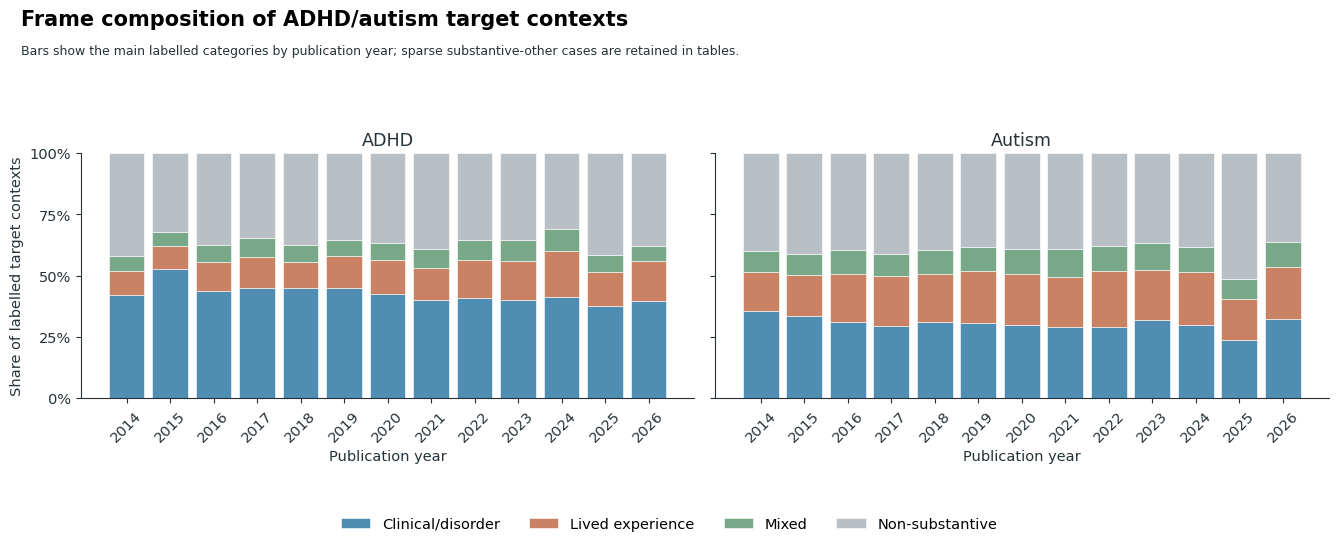

In [4]:
plot_data = figure_data.pivot_table(
    index=["analysis_unit", "lsc_year"],
    columns="predicted_derived_frame",
    values="pct_within_displayed_frames",
    fill_value=0,
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.0), sharey=True)
for ax, unit in zip(axes, TARGET_UNITS):
    unit_data = plot_data[plot_data["analysis_unit"].eq(unit)].sort_values("lsc_year")
    years = unit_data["lsc_year"].astype(int).to_numpy()
    bottom = pd.Series(0.0, index=unit_data.index).to_numpy()
    for frame in DISPLAY_FRAMES:
        values = unit_data.get(frame, pd.Series(0.0, index=unit_data.index)).to_numpy(dtype=float)
        ax.bar(
            years,
            values,
            bottom=bottom,
            color=FRAME_COLOURS[frame],
            label=FRAME_LABELS[frame],
            width=0.82,
            edgecolor="white",
            linewidth=0.4,
        )
        bottom = bottom + values
    ax.set_title(unit)
    ax.set_xlabel("Publication year")
    ax.set_xticks(years)
    ax.tick_params(axis="x", rotation=45)
    ax.set_ylim(0, 1)
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["0%", "25%", "50%", "75%", "100%"])
    ax.grid(axis="y")
    ax.grid(axis="x", visible=False)

axes[0].set_ylabel("Share of labelled target contexts")
handles, labels_for_legend = axes[1].get_legend_handles_labels()
fig.legend(handles, labels_for_legend, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.05))
fig.suptitle("Frame composition of ADHD/autism target contexts", fontsize=15, fontweight="bold", x=0.02, ha="left", y=1.02)
fig.text(0.02, 0.93, "Bars show the main labelled categories by publication year; sparse substantive-other cases are retained in tables.", ha="left", fontsize=9.0, color="#263238")
fig.tight_layout(rect=[0, 0.08, 1, 0.88])

png_path = FIGURE_DIR / "lsc_classification_frame_composition.png"
pdf_path = FIGURE_DIR / "lsc_classification_frame_composition.pdf"
fig.savefig(png_path, dpi=300, bbox_inches="tight", facecolor="white")
fig.savefig(pdf_path, bbox_inches="tight", facecolor="white")
print(f"Wrote {png_path.relative_to(PROJECT_ROOT)}")
print(f"Wrote {pdf_path.relative_to(PROJECT_ROOT)}")


## Handoff Summary

Use the validation table to describe the classifier's adequacy for substantive-discourse and clinical/lived-experience stratification. Use the composition tables and figure to motivate later frame-aware LSC analyses. The classification layer should not be over-interpreted as lexical semantic change by itself.


In [5]:
summary = {
    "target_contexts": int(len(labels)),
    "adhd_contexts": int(labels["analysis_unit"].eq("ADHD").sum()),
    "autism_contexts": int(labels["analysis_unit"].eq("Autism").sum()),
    "codebook_version": EXPECTED_CODEBOOK_VERSION,
    "omitted_from_figure": "substantive_other",
}
summary


{'target_contexts': 96864,
 'adhd_contexts': 28611,
 'autism_contexts': 68253,
 'codebook_version': 'v0.4',
 'omitted_from_figure': 'substantive_other'}